# Class 9: Deep Learning in Practice

Today we will:
- Apply neural networks to a **real task** (MNIST handwritten digits)
- Learn the **Keras API** — the industry standard for deep learning
- Use **regularization** tools specific to deep learning (early stopping, dropout)
- Understand **why deep learning works** (the manifold hypothesis)
- Build our first **Convolutional Neural Network** (CNN)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

prng = np.random.RandomState(20260318)  # for numpy/sklearn reproducibility
tf.random.set_seed(20260318) # for TensorFlow/Keras reproducibility

%precision 3
pd.set_option('display.precision', 3)
sns.set_style('whitegrid')

## Neural network on MNIST (sklearn)

In Class 6 we saw neural networks learn nonlinear decision boundaries on toy circles data (2 features, 2 classes). Now we scale up: **784 features, 10 classes, real images**.

### Load and explore MNIST

MNIST contains 70,000 handwritten digit images:
- 28×28 pixels = 784 features per image
- Grayscale values from 0 (black) to 255 (white)
- 10 classes (digits 0-9)

In [4]:
# Load MNIST from Keras
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.mnist.load_data()

print(f"Training images: {X_train_full.shape}")
print(f"Test images:     {X_test.shape}")
print(f"Pixel range:     [{X_train_full.min()}, {X_train_full.max()}]")

Training images: (60000, 28, 28)
Test images:     (10000, 28, 28)
Pixel range:     [0, 255]


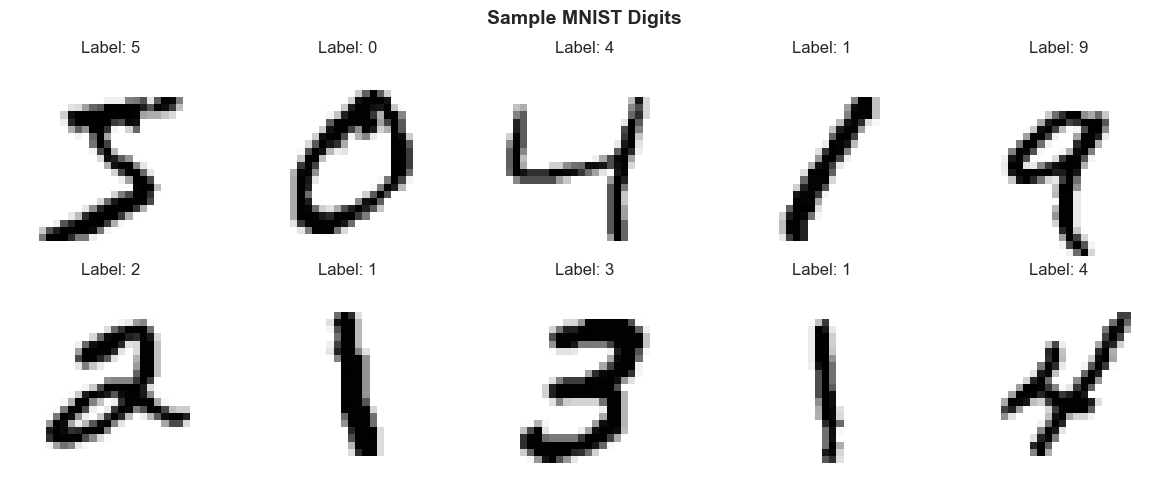

In [39]:
# Show sample digits
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train_full[i], cmap='gray_r')
    ax.set_title(f"Label: {y_train_full[i]}", fontsize=12)
    ax.axis('off')
plt.suptitle("Sample MNIST Digits", fontsize=14, fontweight='bold')
plt.tight_layout()

In [5]:
# Take a random sample of 30,000 images to speed up training while keeping enough data
# for deep learning models to show their advantage over tree-based methods
sample_idx_train = prng.choice(len(X_train_full), 30000, replace=False)
X_train_full_sample = X_train_full[sample_idx_train]
y_train = y_train_full[sample_idx_train]

print(f"Sampled training shape: {X_train_full_sample.shape}")

Sampled training shape: (30000, 28, 28)


### Prepare data for sklearn

Sklearn expects flat feature vectors, so we reshape each 28×28 image into a 784-dimensional vector and scale to [0, 1].

In [6]:
# Flatten and scale for sklearn
X_train_flat = X_train_full_sample.reshape(-1, 784).astype('float32') / 255.0
X_test_flat = X_test.reshape(-1, 784).astype('float32') / 255.0

print(f"Flattened shape: {X_train_flat.shape}")

Flattened shape: (30000, 784)


### Tracking experiments

We'll reuse the `ResultCollector` pattern from the bike share demand notebook (Class 5) to keep an organized comparison of all our models.

In [10]:
class ResultCollector:
    def __init__(self):
        self.results = {}

    def add_model(self, name, train_acc, test_acc):
        """Add or update a model's results."""
        self.results[name] = {
            'Train Accuracy': train_acc,
            'Test Accuracy': test_acc,
            'Gap': train_acc - test_acc
        }
        return self.get_table()

    def get_table(self, style=True):
        """Get the results table with optional styling."""
        df = pd.DataFrame(self.results).T
        if style:
            return df.style.format("{:.4f}", subset=['Train Accuracy', 'Test Accuracy', 'Gap']).background_gradient(cmap='RdYlGn', subset=['Test Accuracy'], axis=None)
        return df

results = ResultCollector()

### Baseline: Logistic Regression

In [43]:
# n_jobs = -1 to use all CPU cores for faster training
log_reg = LogisticRegression(random_state=prng, max_iter=1000, n_jobs=-1)
log_reg.fit(X_train_flat, y_train)

results.add_model(
    'Logistic Regression',
    log_reg.score(X_train_flat, y_train),
    log_reg.score(X_test_flat, y_test)
)

,Train Accuracy,Test Accuracy,Gap
Logistic Regression,0.9456,0.9217,0.0239


### Baseline 2: Random Forest

Random Forest uses ensembles of decision trees, a completely different approach from the linear model. Let's see how a tree-based method handles pixel data.

In [11]:
rf = RandomForestClassifier(random_state=prng, n_jobs=-1)
rf.fit(X_train_flat, y_train)

results.add_model(
    'Random Forest',
    rf.score(X_train_flat, y_train),
    rf.score(X_test_flat, y_test)
)

,Train Accuracy,Test Accuracy,Gap
Random Forest,1.0000,0.9629,0.0371


### Recap: MLP of sklearn

In Class 6, we used `MLPClassifier` on 2D circles. Now let's apply the same tool to 784-dimensional images.

In [45]:
mlp_sklearn = MLPClassifier(random_state=prng)
mlp_sklearn.fit(X_train_flat, y_train)

results.add_model(
    'sklearn MLP',
    mlp_sklearn.score(X_train_flat, y_train),
    mlp_sklearn.score(X_test_flat, y_test)
)

,Train Accuracy,Test Accuracy,Gap
Logistic Regression,0.9456,0.9217,0.0239
Random Forest,1.0000,0.9633,0.0367
sklearn MLP,1.0000,0.9701,0.0299


In [46]:
print(f"Iterations: {mlp_sklearn.n_iter_}") 
mlp_sklearn.get_params()

Iterations: 71


{'activation': 'relu',
 'alpha': 0.000,
 'batch_size': 'auto',
 'beta_1': 0.900,
 'beta_2': 0.999,
 'early_stopping': False,
 'epsilon': 0.000,
 'hidden_layer_sizes': (100,),
 'learning_rate': 'constant',
 'learning_rate_init': 0.001,
 'max_fun': 15000,
 'max_iter': 200,
 'momentum': 0.900,
 'n_iter_no_change': 10,
 'nesterovs_momentum': True,
 'power_t': 0.500,
 'random_state': RandomState(MT19937) at 0x13D830B40,
 'shuffle': True,
 'solver': 'adam',
 'tol': 0.000,
 'validation_fraction': 0.100,
 'verbose': False,
 'warm_start': False}

The MLP beats both baselines. The difference is small, but it's due to the nature of the problem: we're dealing with simple images. The first deep neural network, AlexNet, decreased the benchmark error on a classic image recognition task from 26% to 16%!

The sklearn's `MLP` is limited for neural networks, and occasionally we would need a more powerful tool. So let's switch to Keras & Tensorflow.

## Intro to Keras

Keras is the high-level API for TensorFlow which makes building neural networks feel like stacking LEGO bricks.

### Build the same model in Keras

Let's rebuild our sklearn MLP in Keras using the Sequential API.

In [47]:
keras_mlp = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(100, activation='relu'),
    layers.Dense(10, activation='softmax')
])

keras_mlp.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

**Reading `model.summary()`:**
- Each layer shows its output shape and parameter count
- Parameters = weights + biases (e.g., hidden layer (Dense): 784×100 + 100 = 78,500)
- Total parameters tell us the model's capacity

### Compile and train

Before training, we need to specify:
- **Optimizer**: How to update weights (Adam is sklearn's default: stochastic gradient descent with adaptive learning rate)
- **Loss**: What to minimize (sparse categorical crossentropy for integer class labels - categorical crossentropy gives one-hot-encoded values)
- **Metrics**: What to track during training (accuracy)

For the training, we need to specify:
- **Epochs**: How many times to loop through the entire training set: more epochs = more learning.
- **Batch size**: How many examples to use per gradient update. The full dataset is split into mini-batches; weights are updated after each one. Smaller batches = noisier but more frequent updates.
- **Validation split**: Fraction of training data held out to monitor generalization during training. Not used for weight updates — only for tracking whether the model is overfitting.

In [48]:
keras_mlp.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_mlp = keras_mlp.fit(
    X_train_flat, y_train,
    batch_size=200,
    epochs=mlp_sklearn.n_iter_,
    validation_split=0.1,
    verbose=1
)

Epoch 1/71
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8355 - loss: 0.6277 - val_accuracy: 0.9160 - val_loss: 0.3056
Epoch 2/71
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 990us/step - accuracy: 0.9252 - loss: 0.2670 - val_accuracy: 0.9333 - val_loss: 0.2422
Epoch 3/71
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9409 - loss: 0.2090 - val_accuracy: 0.9407 - val_loss: 0.2106
Epoch 4/71
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9520 - loss: 0.1722 - val_accuracy: 0.9480 - val_loss: 0.1900
Epoch 5/71
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9607 - loss: 0.1460 - val_accuracy: 0.9537 - val_loss: 0.1759
Epoch 6/71
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9671 - loss: 0.1260 - val_accuracy: 0.9570 - val_loss: 0.1656
Epoch 7/71
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9706 - loss: 0.1099 - val_accuracy: 0.9590 - val_loss: 0.1568
Epoch 8/71
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9740 - loss: 0.0966 - val_accuracy: 

### Training curves

One major advantage of Keras: we get full training history. The `history` object contains loss and accuracy for both training and validation at every epoch.

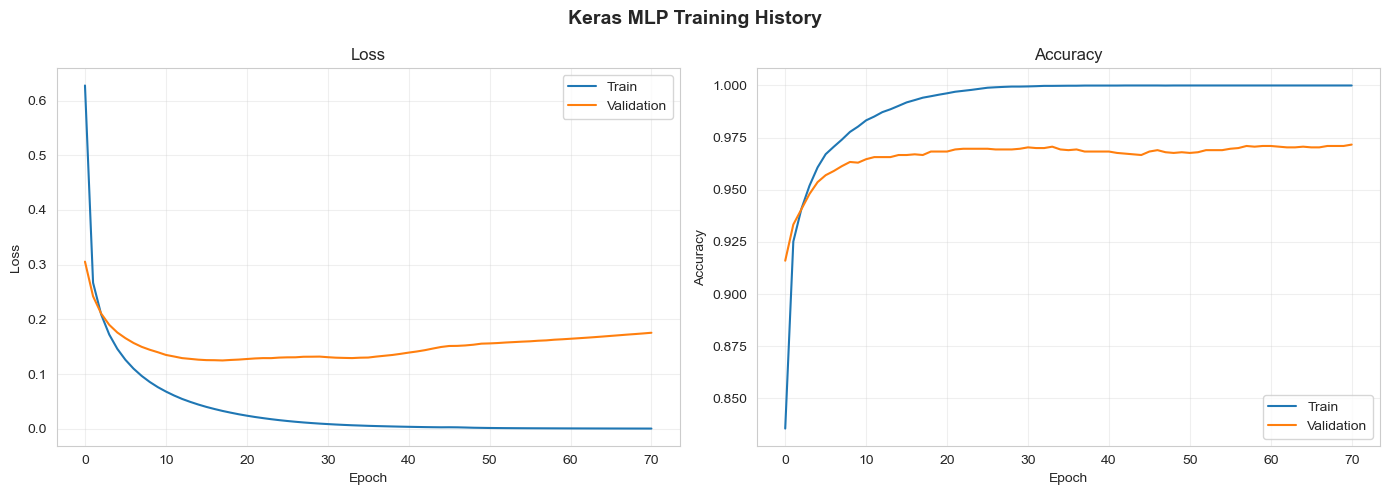

In [49]:
def plot_training_history(history, title="Training History"):
    """Plot training and validation loss/accuracy from a Keras history object."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['loss'], label='Train')
    ax1.plot(history.history['val_loss'], label='Validation')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(history.history['accuracy'], label='Train')
    ax2.plot(history.history['val_accuracy'], label='Validation')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()

plot_training_history(history_mlp, "Keras MLP Training History")

In [50]:
train_loss, train_acc = keras_mlp.evaluate(X_train_flat, y_train, verbose=0)
test_loss, test_acc = keras_mlp.evaluate(X_test_flat, y_test, verbose=0)

results.add_model('Keras MLP', train_acc, test_acc)

,Train Accuracy,Test Accuracy,Gap
Logistic Regression,0.9456,0.9217,0.0239
Random Forest,1.0000,0.9633,0.0367
sklearn MLP,1.0000,0.9701,0.0299
Keras MLP,0.9972,0.9692,0.0280


Keras achieves similar accuracy to sklearn: same thing, more control. For small networks like this, sklearn is genuinely faster. Keras's overhead pays off when you need advanced features (see later) and have large datasets.

## Regularization

From Class 4, you know the bias-variance trade-off: more flexibility means better fit to training data but risk of overfitting. We see that our models already memorized the full training data and started to overfit, but they generalize surprisingly well. Let's try to overfit even more and see if test accuracy starts decreasing.

### Setup: Large network

Let's train a **larger** network (256, 256, 256) for many epochs and watch it overfit.

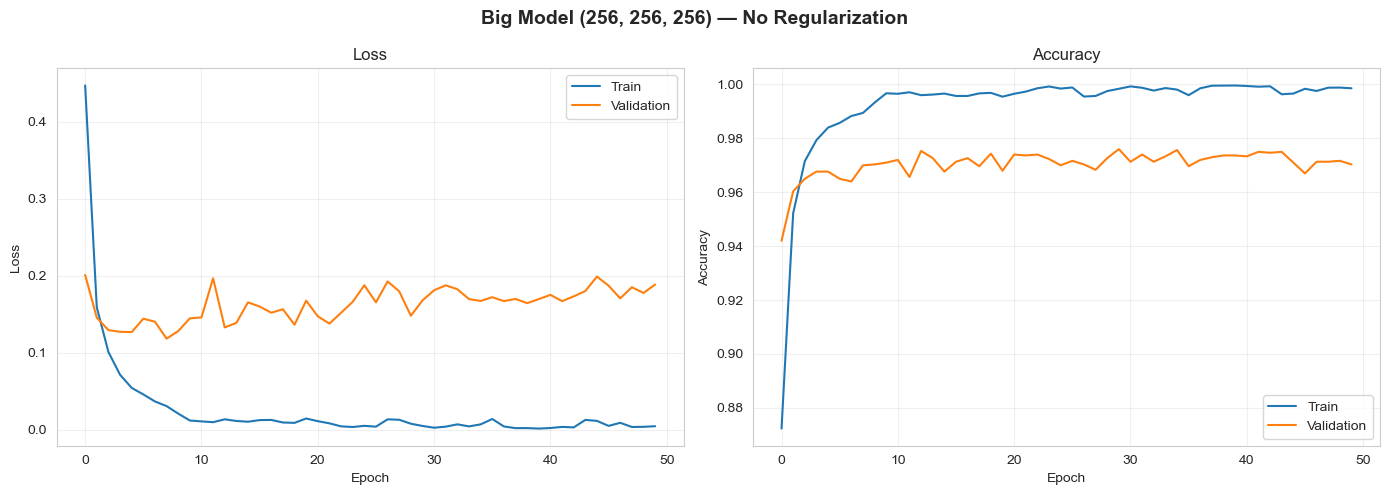

In [51]:
tf.random.set_seed(20260318) # Reset seed to ensure within-cell reproducibility for the big model

big_model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

big_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_big = big_model.fit(
    X_train_flat, y_train,
    epochs=50,
    batch_size=200,
    validation_split=0.1,
    verbose=0
)

plot_training_history(history_big, "Big Model (256, 256, 256) — No Regularization")

In [52]:
train_loss, train_acc = big_model.evaluate(X_train_flat, y_train, verbose=0)
test_loss, test_acc = big_model.evaluate(X_test_flat, y_test, verbose=0)

results.add_model('Big MLP (no reg)', train_acc, test_acc)

,Train Accuracy,Test Accuracy,Gap
Logistic Regression,0.9456,0.9217,0.0239
Random Forest,1.0000,0.9633,0.0367
sklearn MLP,1.0000,0.9701,0.0299
Keras MLP,0.9972,0.9692,0.0280
Big MLP (no reg),0.9937,0.9702,0.0235


**Notice something surprising:** the gap between train and test accuracy actually decreased, even if validation loss is clearly incrasing! The model memorizes the full training data, but it also generalizes well. Why?? Can we improve the models even further with DL-specific regularization techniques?

### Tool 1: Early Stopping

The simplest and most universally useful regularization in deep learning: **stop training when validation performance stops improving**.

Keras provides this as a *callback*: a function that runs at the end of each epoch.

Stopped at epoch 10 (out of max 50)


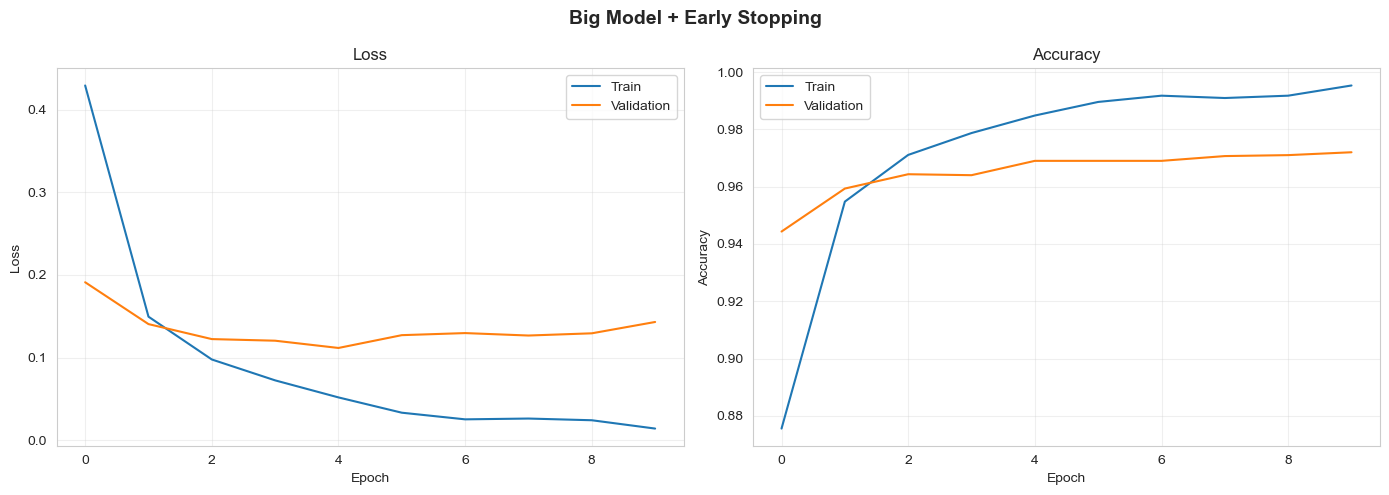

In [53]:
tf.random.set_seed(20260318)

es_model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

es_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_es = es_model.fit(
    X_train_flat, y_train,
    epochs=50,
    batch_size=200,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=0
)

print(f"Stopped at epoch {len(history_es.history['loss'])} (out of max 50)")
plot_training_history(history_es, "Big Model + Early Stopping")

In [54]:
train_loss, train_acc = es_model.evaluate(X_train_flat, y_train, verbose=0)
test_loss, test_acc = es_model.evaluate(X_test_flat, y_test, verbose=0)

results.add_model('Big MLP + Early Stopping', train_acc, test_acc)

,Train Accuracy,Test Accuracy,Gap
Logistic Regression,0.9456,0.9217,0.0239
Random Forest,1.0000,0.9633,0.0367
sklearn MLP,1.0000,0.9701,0.0299
Keras MLP,0.9972,0.9692,0.0280
Big MLP (no reg),0.9937,0.9702,0.0235
Big MLP + Early Stopping,0.9887,0.9684,0.0203


Early stopping monitors validation loss and stops training when it stops improving. `restore_best_weights=True` is important: it rolls back to the best epoch, not just the last one before stopping.

**On MNIST, early stopping doesn't improve test accuracy**: the model learns useful features even while overfitting, so stopping early means learning *less*. But on harder datasets (you'll see this in Assignment 3 with Fashion-MNIST), early stopping prevents real damage to generalization.

**When to use it:** Early stopping is cheap insurance as it costs nothing and prevents wasted compute. Always include it as a default (as sklearn does).

### Tool 2: Dropout

The idea: **randomly disable neurons during training**. At each training step, each neuron in a Dropout layer has a probability *p* of being "dropped" (output set to zero).

Why does this help?
- Forces the network to learn **redundant representations** as it can't rely on any single neuron
- Acts like training many different sub-networks and averaging them
- Similar idea to random forests that use sampling techniques to grow uncorrelated trees

(This is an advanced feature sklearn does not provide.)

In [12]:
tf.random.set_seed(20260318)

dropout_model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

dropout_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_dropout = dropout_model.fit(
    X_train_flat, y_train,
    epochs=50,
    batch_size=200,
    validation_split=0.1,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True
    )],
    verbose=0
)

print(f"Stopped at epoch {len(history_dropout.history['loss'])}")
plot_training_history(history_dropout, "Big Model + Dropout (0.3) + Early Stopping")

Stopped at epoch 22


NameError: name 'plot_training_history' is not defined

In [56]:
train_loss, train_acc = dropout_model.evaluate(X_train_flat, y_train, verbose=0)
test_loss, test_acc = dropout_model.evaluate(X_test_flat, y_test, verbose=0)

results.add_model('Big MLP + Dropout + ES', train_acc, test_acc)

,Train Accuracy,Test Accuracy,Gap
Logistic Regression,0.9456,0.9217,0.0239
Random Forest,1.0000,0.9633,0.0367
sklearn MLP,1.0000,0.9701,0.0299
Keras MLP,0.9972,0.9692,0.0280
Big MLP (no reg),0.9937,0.9702,0.0235
Big MLP + Early Stopping,0.9887,0.9684,0.0203
Big MLP + Dropout + ES,0.9947,0.9766,0.0181


### Comparing training curves

Let's put the three variants side by side to see the effect of regularization on the **train-validation gap**.

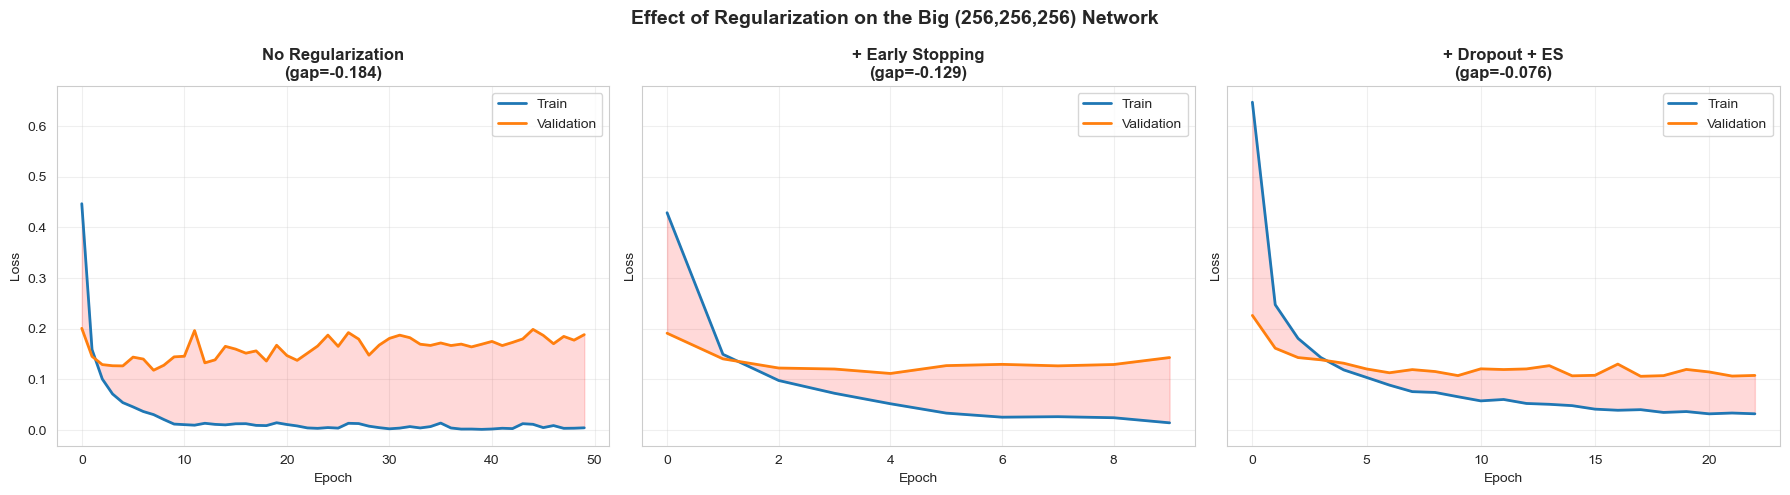

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

histories = [
    (history_big, "No Regularization"),
    (history_es, "+ Early Stopping"),
    (history_dropout, "+ Dropout + ES")
]

for ax, (hist, title) in zip(axes, histories):
    ax.plot(hist.history['loss'], label='Train', linewidth=2)
    ax.plot(hist.history['val_loss'], label='Validation', linewidth=2)
    gap = hist.history['loss'][-1] - hist.history['val_loss'][-1]
    ax.fill_between(
        range(len(hist.history['loss'])),
        hist.history['loss'],
        hist.history['val_loss'],
        alpha=0.15, color='red'
    )
    ax.set_title(f"{title}\n(gap={gap:.3f})", fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Effect of Regularization on the Big (256,256,256) Network", fontsize=14, fontweight='bold')
plt.tight_layout()

**What to observe:**
- **Left panel (no regularization):** The red shaded gap grows steadily: the model keeps memorizing while validation stalls. Training runs all 50 epochs.
- **Middle panel (early stopping):** Training is cut short, preventing further gap growth. But with it, learning time is also cut short.
- **Right panel (dropout + ES):** Dropout slows down memorization (notice training loss decreases more gradually), keeping train and validation curves closer together. The model trains longer before early stopping triggers.

On MNIST, all three models achieve similar test accuracy, and the unregularized model actually scores highest!
How could we reconcile this with our previous knowledge?

1. The stochastic gradient descent algorithm itself is a regularizer: the stochastic nature of it aims to find flat minima, stable solutions that generalize well. So there is no "unregularized" model in deep learning like the one we saw with very deep trees. This explains why regularized and (seemingly) unregularized models perform similarly.

2. Deep learning lead to a surprising discovery: for overparametrized models, the classical bias-variance trade-off behave differently and we can observe a double descent phenomenon (Belkin et al. 2019).

3. The MNIST digit dataset is "easy enough": more training (even past the point of overfitting) means more learning. However, on harder problems (like Fashion-MNIST in Assignment 3, real-world images), overfitting *could* harm generalization. Thought experiment: What would happen if we randomly reshuffled the digit labels on the images? What accuracy could the same models achieve in train and test sets?

## "Easy enough": The Manifold Hypothesis

### The paradox

Curse of dimensionality (Class 1) says: high dimensions make predictions infeasibly hard. 
But deep networks with many features and **millions** of parameters generalize well. Why?

### The manifold hypothesis

Real-world high-dimensional data (images, text) doesn't fill the full space. It lives on a much **lower-dimensional manifold**.

Think about it: a 28×28 image has 784 dimensions. But not every combination of 784 pixel values is a valid digit. The "manifold of valid digit images" is tiny compared to all possible 784-pixel arrays. Most random pixel combinations look like TV static, not handwritten digits.

Neural networks learn this manifold structure as each neurons learn a **nonlinear projection** to the relevant subspace.

### Seeing the manifold: random pixels vs real digits

Let's make this concrete. If images were uniformly distributed in the 784-dimensional pixel space, a random sample would look like... what?

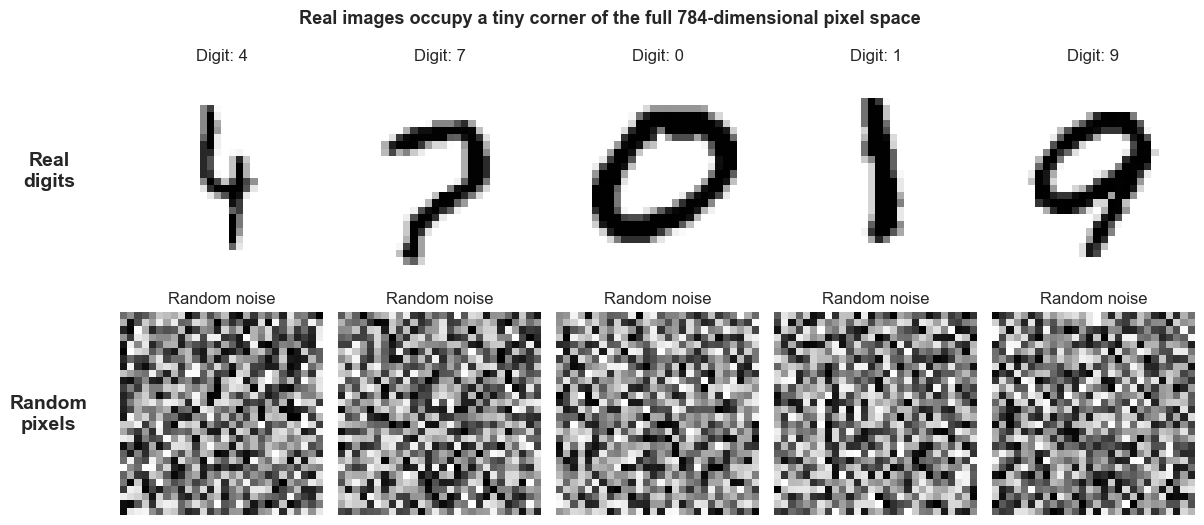

In [7]:
# Real digits vs random pixel noise
fig, axes = plt.subplots(2, 5, figsize=(12, 5.5))

# Top row: 5 random real digits
real_idx = prng.choice(len(X_train_flat), 5, replace=False)
for i, idx in enumerate(real_idx):
    axes[0, i].imshow(X_train_flat[idx].reshape(28, 28), cmap='gray_r')
    axes[0, i].set_title(f"Digit: {y_train[idx]}", fontsize=12)
    axes[0, i].axis('off')

# Bottom row: 5 random noise images (each pixel sampled uniformly)
for i in range(5):
    random_img = prng.rand(28, 28)  # uniform [0, 1]
    axes[1, i].imshow(random_img, cmap='gray_r')
    axes[1, i].set_title("Random noise", fontsize=12)
    axes[1, i].axis('off')

# Row labels
axes[0, 0].annotate("Real\ndigits", xy=(-0.35, 0.5), xycoords='axes fraction',
                     fontsize=14, fontweight='bold', ha='center', va='center')
axes[1, 0].annotate("Random\npixels", xy=(-0.35, 0.5), xycoords='axes fraction',
                     fontsize=14, fontweight='bold', ha='center', va='center')

plt.suptitle("Real images occupy a tiny corner of the full 784-dimensional pixel space",
             fontsize=13, fontweight='bold')
plt.tight_layout()

Each image has 784 pixels, each taking values 0-255. That's $256^{784}$ possible images! But no random image looks anything like a handwritten digit. Real digit images live on a thin, low-dimensional manifold within this vast space. For another insightful visualization, look at this great [post](https://colah.github.io/posts/2014-10-Visualizing-MNIST/#:~:text=In%20this%20visualization,on%20that%20axis.) by Chris Olah.

### Trees vs neural networks: a concrete comparison

We claimed that trees work on raw pixel values while neural networks learn new representations. Let's see this in action. Where does our Random Forest fail that the neural network succeeds?

Error comparison (10,000 test images):


,RF correct,RF wrong
,,
NN correct,9552,77
NN wrong,204,167


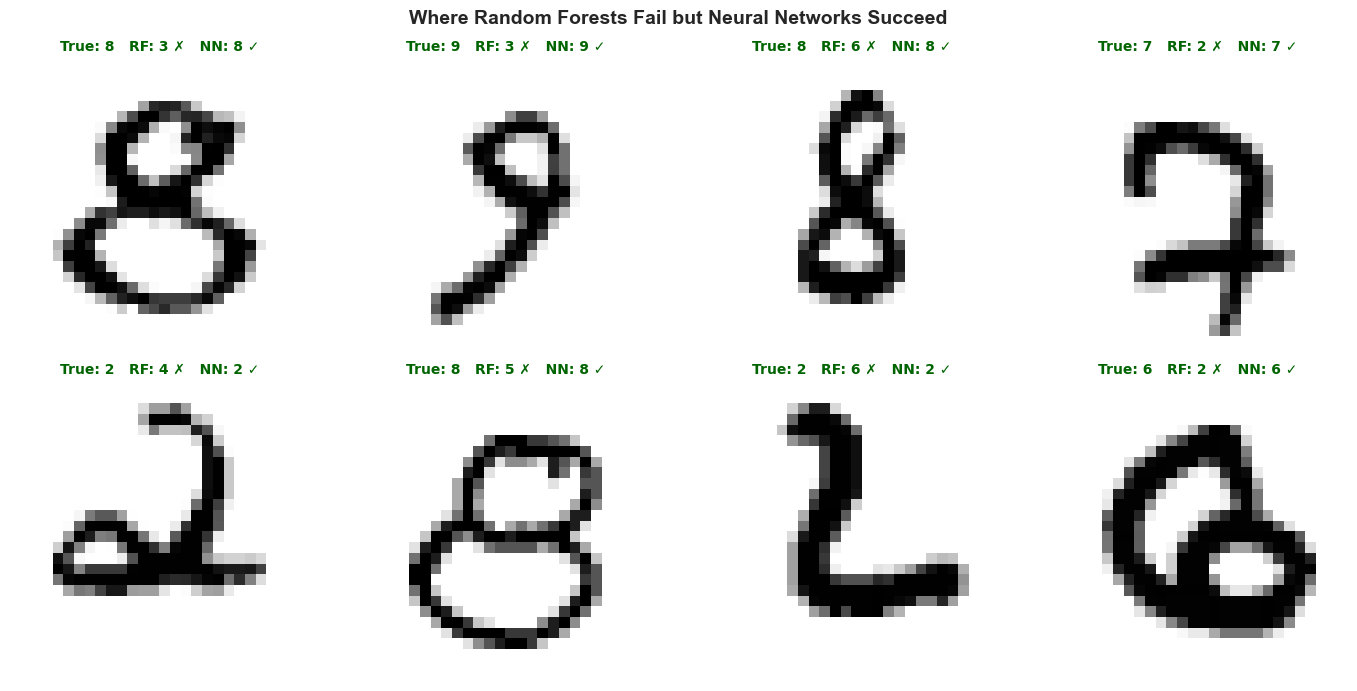

In [13]:
# Compare RF and NN predictions on the test set
rf_preds = rf.predict(X_test_flat)
nn_preds = np.argmax(dropout_model.predict(X_test_flat, verbose=0), axis=1)

# Error comparison table
rf_wrong_nn_right = np.where((rf_preds != y_test) & (nn_preds == y_test))[0]
nn_wrong_rf_right = np.where((rf_preds == y_test) & (nn_preds != y_test))[0]
both_right = np.sum((rf_preds == y_test) & (nn_preds == y_test))
both_wrong = np.sum((rf_preds != y_test) & (nn_preds != y_test))

confusion = pd.DataFrame(
    [[both_right, len(nn_wrong_rf_right)],
     [len(rf_wrong_nn_right), both_wrong]],
    index=pd.Index(['NN correct', 'NN wrong'], name=''),
    columns=pd.Index(['RF correct', 'RF wrong'], name='')
)
print("Error comparison (10,000 test images):")
display(confusion)

# Show 8 random examples where RF fails but NN succeeds
show_idx = prng.choice(rf_wrong_nn_right, 8, replace=False)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, idx in enumerate(show_idx):
    ax = axes[i // 4, i % 4]
    ax.imshow(X_test_flat[idx].reshape(28, 28), cmap='gray_r')
    ax.set_title(f"True: {y_test[idx]}   RF: {rf_preds[idx]} \u2717   NN: {y_test[idx]} \u2713",
                 fontsize=10, fontweight='bold', color='darkgreen',
                 fontfamily='DejaVu Sans')
    ax.axis('off')
plt.suptitle("Where Random Forests Fail but Neural Networks Succeed",
             fontsize=14, fontweight='bold')
plt.tight_layout()

The table shows a clear asymmetry: there are twice as many cases where the RF fails and the NN succeeds than vice versa. The images above are random samples from those cases: atypical, messy digits that are shifted, rotated, or unusually styled. The Random Forest classifies by comparing raw pixel values, so it struggles when the same digit *looks* different at the pixel level. The neural network succeeds because it has learned to recognize structural patterns (curves, strokes) rather than matching raw pixels.

**Discussion:** Look at the digits above. Can you see why the RF made the mistakes it did? What pixel-level similarities might have confused it?

### What does "nearby" mean? Pixel space vs learned representation

This is the key difference between trees and neural networks. Let's take some of these digits where the RF failed and ask: what are their **nearest neighbors** in pixel space vs in the network's hidden layer?

Dimension of the pixel space: 784
Dimension of the hidden representation: 256


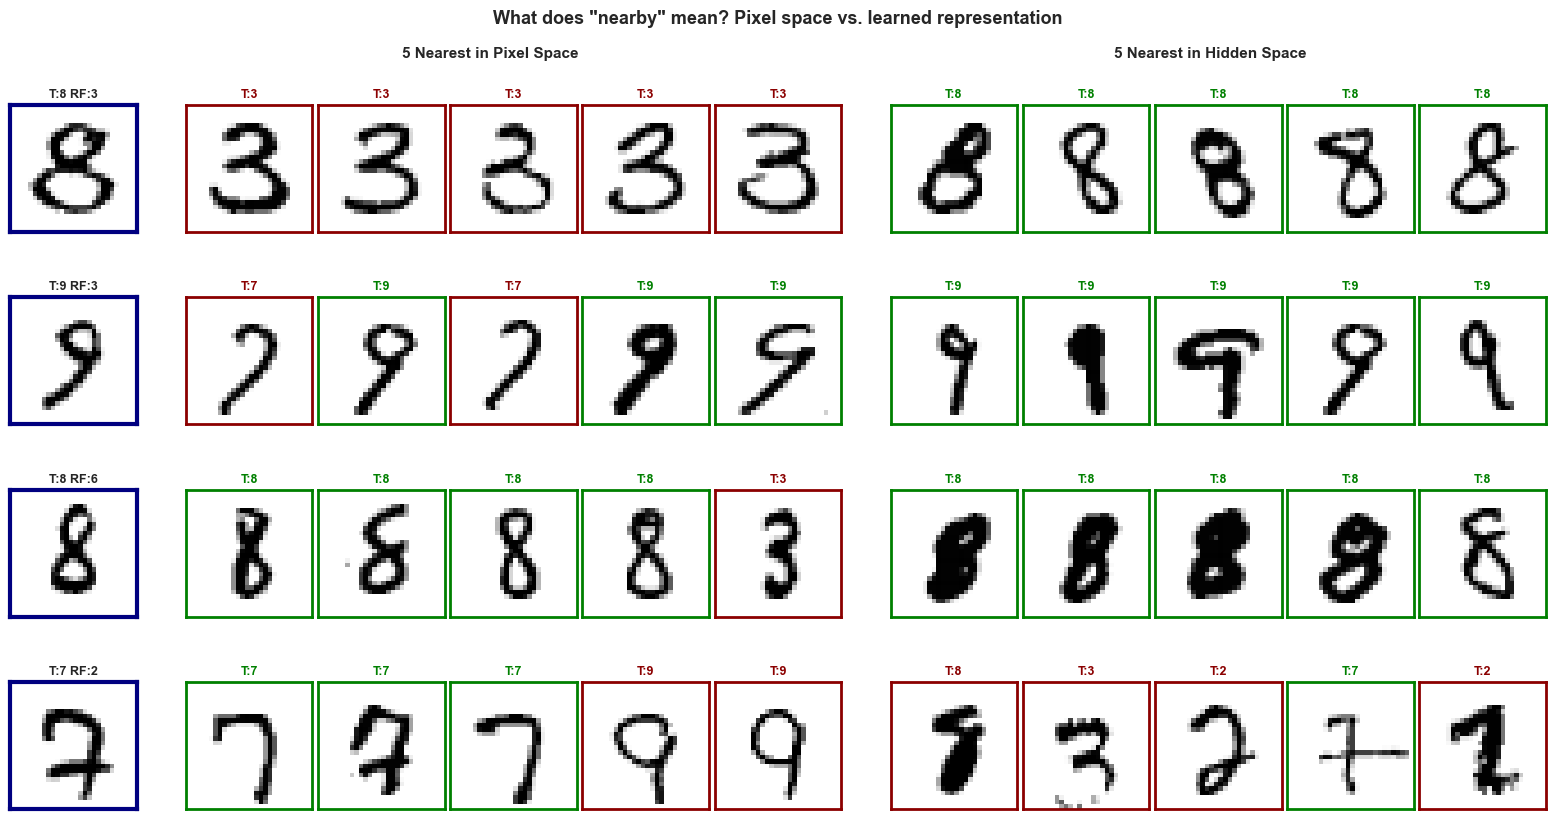

In [15]:
from sklearn.neighbors import NearestNeighbors
from matplotlib.gridspec import GridSpec
prng = np.random.RandomState(20260318)  # reset for reproducibility of neighbor selection

# Extract hidden representations for the full test set
# layers[-2] is the last Dropout layer — at inference time, Dropout is a pass-through,
# so this is equivalent to the output of the last Dense(256) hidden layer.
hidden_model = keras.Model(inputs=dropout_model.inputs, outputs=dropout_model.layers[-2].output)
X_test_hidden = hidden_model.predict(X_test_flat, verbose=0)

# Build nearest-neighbor indices
K = 5
nn_pixel = NearestNeighbors(n_neighbors=K + 1, metric='euclidean').fit(X_test_flat)
nn_hidden = NearestNeighbors(n_neighbors=K + 1, metric='euclidean').fit(X_test_hidden)
print("Dimension of the pixel space:", X_test_flat.shape[1])
print("Dimension of the hidden representation:", X_test_hidden.shape[1])


# Pick first 4 images from the above comparison
query_indices = show_idx[:4]

# Layout with 3 groups separated by narrow gaps: [query] gap [5 pixel-NN] gap [5 hidden-NN]
n_rows = len(query_indices)
# Columns: 1 query + 1 gap + 5 pixel + 1 gap + 5 hidden = 13
width_ratios = [1] + [0.3] + [1]*K + [0.3] + [1]*K
fig = plt.figure(figsize=(16, n_rows * 2))
gs = GridSpec(n_rows, len(width_ratios), figure=fig,
              width_ratios=width_ratios, wspace=0.05, hspace=0.35)

for row_i, q_idx in enumerate(query_indices):
    true_label = y_test[q_idx]
    rf_pred = rf_preds[q_idx]
    col = 0

    # Query image (blue border)
    ax = fig.add_subplot(gs[row_i, col])
    ax.imshow(X_test_flat[q_idx].reshape(28, 28), cmap='gray_r')
    ax.set_title(f"T:{true_label} RF:{rf_pred}", fontsize=9, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('navy'); spine.set_linewidth(3)
    col += 1

    col += 1  # skip spacer column

    # Pixel-space neighbors
    _, idx_px = nn_pixel.kneighbors(X_test_flat[q_idx:q_idx + 1])
    for k in range(K):
        nb_idx = idx_px[0, k + 1]
        label = y_test[nb_idx]
        color = 'green' if label == true_label else 'darkred'
        ax = fig.add_subplot(gs[row_i, col])
        ax.imshow(X_test_flat[nb_idx].reshape(28, 28), cmap='gray_r')
        ax.set_title(f"T:{label}", fontsize=9, color=color, fontweight='bold')
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor(color); spine.set_linewidth(2)
        col += 1

    col += 1  # skip spacer column

    # Hidden-space neighbors
    _, idx_hd = nn_hidden.kneighbors(X_test_hidden[q_idx:q_idx + 1])
    for k in range(K):
        nb_idx = idx_hd[0, k + 1]
        label = y_test[nb_idx]
        color = 'green' if label == true_label else 'darkred'
        ax = fig.add_subplot(gs[row_i, col])
        ax.imshow(X_test_flat[nb_idx].reshape(28, 28), cmap='gray_r')
        ax.set_title(f"T:{label}", fontsize=9, color=color, fontweight='bold')
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor(color); spine.set_linewidth(2)
        col += 1

# Section labels
fig.text(0.32, 0.97, "5 Nearest in Pixel Space",
         ha='center', fontsize=11, fontweight='bold')
fig.text(0.77, 0.97, "5 Nearest in Hidden Space",
         ha='center', fontsize=11, fontweight='bold')
plt.suptitle('What does "nearby" mean? Pixel space vs. learned representation',
             fontsize=13, fontweight='bold', y=1.03)
plt.subplots_adjust(left=0.02, right=0.98, top=0.92, bottom=0.02)

This is the manifold hypothesis made visible:

- **Pixel space** (middle): "nearby" means similar brightness patterns. The nearest neighbors have similar pixel values but are often *completely different digits*. A tree-based model that splits on pixel values would make the same mistakes.
- **Hidden space** (right): "nearby" means the network considers them structurally similar. All neighbors are the correct digit class, despite looking very different at the pixel level.

The neural network has learned to project the data onto a manifold where **semantic similarity** (same digit) aligns with **geometric proximity** (nearby in hidden space). This is fundamentally different from what tree ensembles can do.

### Why tree ensembles are different

- Trees partition the *full* feature space with axis-aligned splits so they work directly on pixel values
- They don't learn a compressed representation but they brute-force the space
- NNs learn to *transform* features first, *then* classify -> that's why they scale to images, text, audio which have clear inherent structures

*Discussion:* Why might neural networks struggle on tabular data compared to XGBoost?

<details>
<summary>Answer</summary>

Tabular features are already meaningful (e.g., temperature, hour, income) — trees can split on them directly without learning a new representation. Neural networks need to *learn* that these features matter, which requires more data and careful tuning. Trees also handle mixed feature types (categorical + numeric) and irregular relationships naturally through axis-aligned splits, while NNs assume smooth, continuous patterns. In short: the inductive bias of trees matches tabular data better, just as the inductive bias of CNNs matches images better. Neural networks are designed to exploit structure in the input space. When that structure doesn't exist, their architectural assumptions become liabilities, not assets.</details>

### Visualizing learned representations

We can use PCA (Class 2) to visualize what the network has learned in its hidden layers. If the network has learned good representations, digit classes should be well-separated in the hidden layer space — even when projected down to just 2 dimensions.

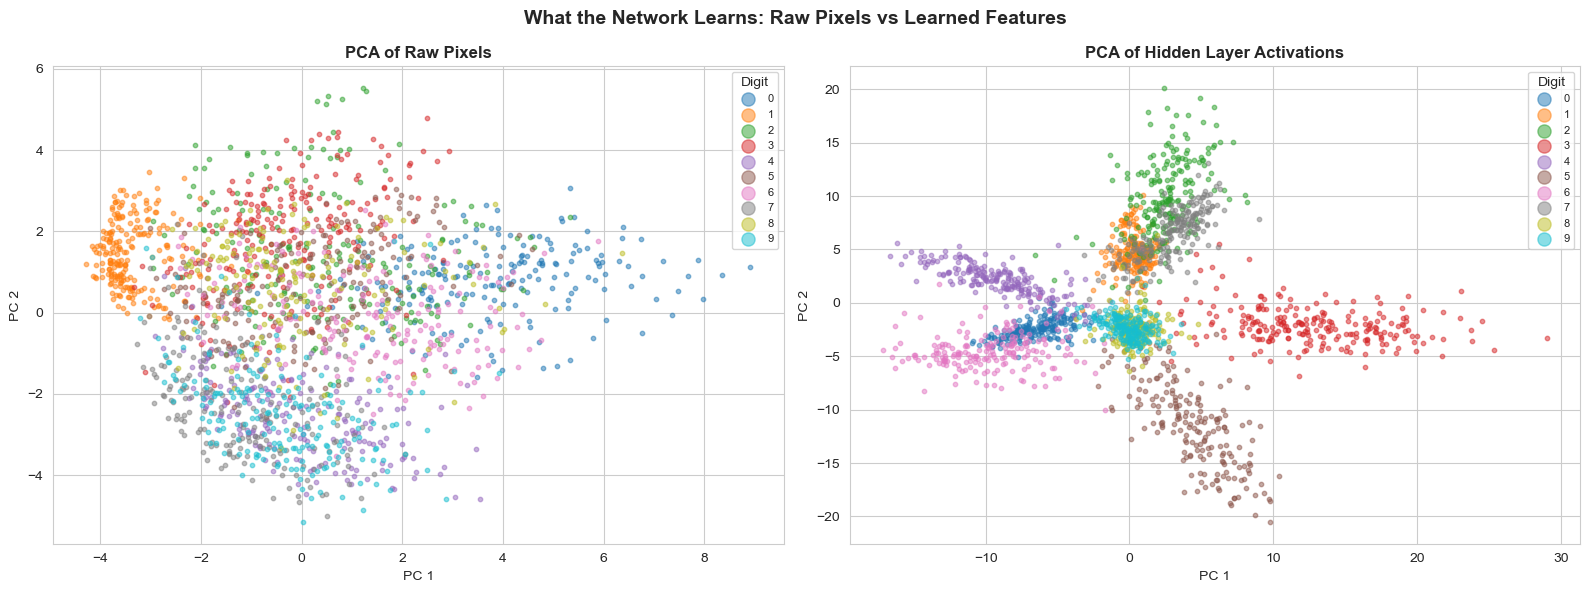

In [16]:
from sklearn.decomposition import PCA

# Use a subset for speed
sample_idx = prng.choice(len(X_test_flat), 2000, replace=False)
X_sample = X_test_flat[sample_idx]
y_sample = y_test[sample_idx]

# Get hidden representations (hidden_model already built above)
hidden_activations = hidden_model.predict(X_sample, verbose=0)

# PCA on raw pixels vs hidden representations
pca_raw = PCA(n_components=2, random_state=20260318).fit_transform(X_sample)
pca_hidden = PCA(n_components=2, random_state=20260318).fit_transform(hidden_activations)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for digit in range(10):
    mask = y_sample == digit
    ax1.scatter(pca_raw[mask, 0], pca_raw[mask, 1], label=str(digit), alpha=0.5, s=10)
    ax2.scatter(pca_hidden[mask, 0], pca_hidden[mask, 1], label=str(digit), alpha=0.5, s=10)

ax1.set_title("PCA of Raw Pixels", fontsize=12, fontweight='bold')
ax1.legend(title='Digit', fontsize=8, markerscale=3)
ax1.set_xlabel('PC 1'); ax1.set_ylabel('PC 2')

ax2.set_title("PCA of Hidden Layer Activations", fontsize=12, fontweight='bold')
ax2.legend(title='Digit', fontsize=8, markerscale=3)
ax2.set_xlabel('PC 1'); ax2.set_ylabel('PC 2')

plt.suptitle("What the Network Learns: Raw Pixels vs Learned Features", fontsize=14, fontweight='bold')
plt.tight_layout()

The network's hidden layer has learned to **separate digit classes** much more cleanly than the raw pixel space. This is the manifold hypothesis in action: the network discovered a low-dimensional structure where digits are easy to tell apart.

**Connection to Class 2:** PCA on raw pixels already shows *some* structure (recall our economic indicators example), but the neural network's learned features make class separation dramatically clearer — even with a *linear* projection method like PCA.

## CNNs: Exploiting Image Structure

### The problem with Dense layers on images

Our Dense network treats each pixel independently:
- 784 inputs × 256 neurons = ~200K parameters in *one* layer
- No spatial awareness: adjacent pixels treated the same as distant pixels
- A slightly shifted digit looks completely different to a Dense layer

**Key idea:** What if we used a small filter that slides across the image? Each filter detects a local pattern (edge, corner, curve) anywhere in the image. This gives us:
- **Weight sharing**: Same filter applied everywhere → fewer parameters
- **Local patterns**: Each filter looks at a small region → spatial awareness
- **Translation invariance**: A "3" in the top-left uses the same filter as a "3" in the bottom-right

### Build a CNN step by step

First, we need to reshape our data. Dense layers want flat vectors (N, 784). CNNs want image tensors with height, width, and channels: (N, 28, 28, 1).

In [62]:
# Reshape for CNN: (N, 28, 28, 1) — the "1" is the single grayscale channel
X_train_cnn = X_train_full_sample.astype('float32') / 255.0
X_train_cnn = X_train_cnn[..., np.newaxis]  # add channel dimension

X_test_cnn = X_test.astype('float32') / 255.0
X_test_cnn = X_test_cnn[..., np.newaxis]

print(f"CNN input shape: {X_train_cnn.shape}")

CNN input shape: (30000, 28, 28, 1)


In [63]:
tf.random.set_seed(20260318)

cnn_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    # First convolutional block
    layers.Conv2D(32, (3, 3), activation='relu'),  # 32 local 3x3 filters
    layers.MaxPooling2D((2, 2)),                    # downsample by half

    # Second convolutional block
    layers.Conv2D(64, (3, 3), activation='relu'),  # 64 higher-level filters
    layers.MaxPooling2D((2, 2)),                    # further downsample

    # Classification head
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

cnn_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

**Reading the CNN architecture:**

- **Conv2D(32, (3,3))**: 32 filters, each 3×3 pixels. Each filter slides across the image detecting a specific local pattern (edges, corners, etc.). Weight sharing means the same 3×3 filter is reused at every position.
- **MaxPooling2D((2,2))**: Takes the maximum value in each 2×2 block. This downsamples the image (halves spatial dimensions) and provides some translation invariance.
- **Flatten()**: Converts the 2D feature maps into a 1D vector for the final Dense layer.

**Making sense of the parameter counts**:

- **Layer 1: Conv2D(32, (3,3)) → 320 parameters**
    - Each filter is 3×3 pixels and looks at 1 input channel (grayscale)
    - Each filter has one bias term
    - Parameters per filter: (3 × 3 × 1) + 1 = 10
    - We have 32 filters: 32 × 10 = **320 parameters**

- **Layer 2: MaxPooling2D((2,2)) → 0 parameters**
    - Pooling just takes the max -> no learnable weights

- **Layer 3: Conv2D(64, (3,3)) → 18,496 parameters**
    - Each filter is 3×3 pixels and looks at 32 input channels (output of previous layer) -> sum up all 32 responses into one output
    - Parameters per filter: (3 × 3 × 32) + 1 = 289
    - We have 64 filters: 64 × 289 = **18,496 parameters**
- **Layer 4: MaxPooling2D((2,2)) → 0 parameters**
- **Layer 5: Flatten() → 0 parameters**
- **Layer 6: Dropout(0.5) → 0 parameters**
- **Layer 7: Dense(10) → 16,010 parameters**
    - Input: 1,600 values (from flattened 5×5×64 feature maps)
    - Output: 10 classes
    - Parameters: (1,600 × 10) + 10 = **16,010 parameters**

Notice the parameter count: much fewer than our Dense equivalent, despite being more powerful for images. The key is **weight sharing**: the same 3×3 filter is reused across the entire image instead of learning separate weights for every pixel position.

Epoch 1/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8340 - loss: 0.5722 - val_accuracy: 0.9603 - val_loss: 0.1449
Epoch 2/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9534 - loss: 0.1558 - val_accuracy: 0.9737 - val_loss: 0.0963
Epoch 3/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9639 - loss: 0.1175 - val_accuracy: 0.9797 - val_loss: 0.0791
Epoch 4/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9716 - loss: 0.0945 - val_accuracy: 0.9823 - val_loss: 0.0675
Epoch 5/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9744 - loss: 0.0826 - val_accuracy: 0.9847 - val_loss: 0.0628
Epoch 6/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9777 - loss: 0.0715 - val_accuracy: 0.9847 - val_loss: 0.0579
Epoch 7/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9802 - loss: 0.0643 - val_accuracy: 0.9863 - val_loss: 0.0556
Epoch 8/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9818 - loss: 0.0591 - val_accu

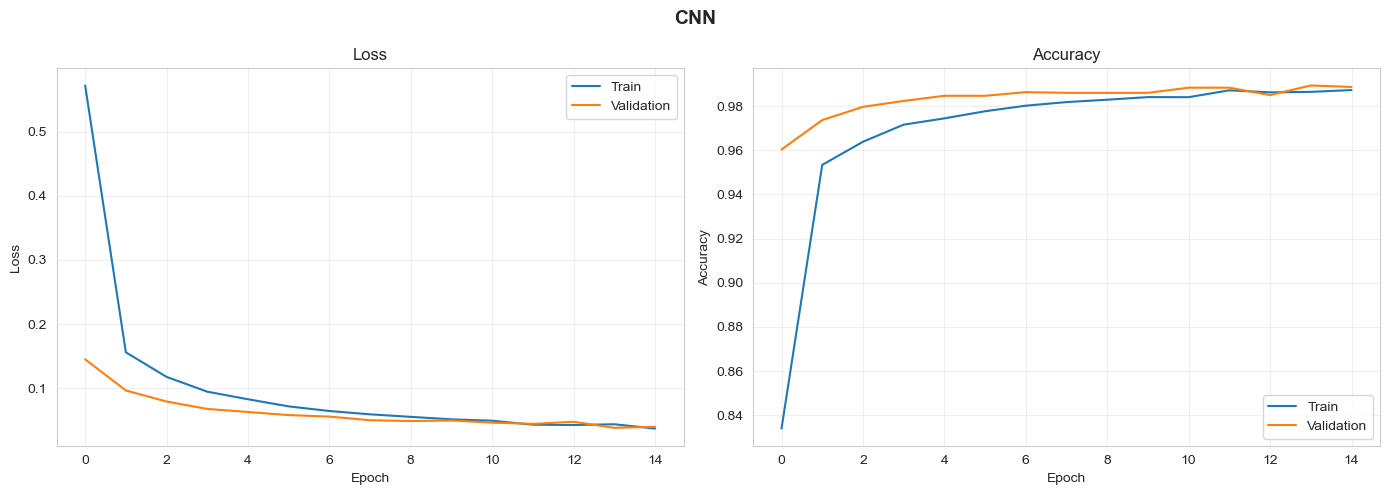

In [64]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_cnn = cnn_model.fit(
    X_train_cnn, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.1,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=3, restore_best_weights=True
    )],
    verbose=1
)

plot_training_history(history_cnn, "CNN")

In [65]:
train_loss, train_acc = cnn_model.evaluate(X_train_cnn, y_train, verbose=0)
test_loss, test_acc = cnn_model.evaluate(X_test_cnn, y_test, verbose=0)

results.add_model('CNN', train_acc, test_acc)

,Train Accuracy,Test Accuracy,Gap
Logistic Regression,0.9456,0.9217,0.0239
Random Forest,1.0000,0.9633,0.0367
sklearn MLP,1.0000,0.9701,0.0299
Keras MLP,0.9972,0.9692,0.0280
Big MLP (no reg),0.9937,0.9702,0.0235
Big MLP + Early Stopping,0.9887,0.9684,0.0203
Big MLP + Dropout + ES,0.9947,0.9766,0.0181
CNN,0.9926,0.9883,0.0043


### Parameter comparison

Let's compare the CNN with our Dense models.

In [66]:
models_to_compare = {
    'Keras MLP (100,)': keras_mlp,
    'Big MLP (256,256,256)': big_model,
    'CNN': cnn_model
}

for name, model in models_to_compare.items():
    n_params = model.count_params()
    print(f"{name:30s} | {n_params:>10,} parameters")

Keras MLP (100,)               |     79,510 parameters
Big MLP (256,256,256)          |    335,114 parameters
CNN                            |     34,826 parameters


The CNN achieves the best accuracy with significantly fewer parameters than the big Dense network. By exploiting spatial structure (local filters + weight sharing), CNNs are **more parameter-efficient** for image data.

### Final result table

In [67]:
results.get_table()

,Train Accuracy,Test Accuracy,Gap
Logistic Regression,0.9456,0.9217,0.0239
Random Forest,1.0000,0.9633,0.0367
sklearn MLP,1.0000,0.9701,0.0299
Keras MLP,0.9972,0.9692,0.0280
Big MLP (no reg),0.9937,0.9702,0.0235
Big MLP + Early Stopping,0.9887,0.9684,0.0203
Big MLP + Dropout + ES,0.9947,0.9766,0.0181
CNN,0.9926,0.9883,0.0043



---

## Key Takeaways

1. **Keras gives us tools sklearn can't**: dropout, CNNs, training curves, fine-grained control
2. **Regularization in DL = early stopping + dropout** — your default toolkit
3. **Deep learning works because data lives on low-dimensional manifolds** — NNs learn that structure (connecting back to PCA from Class 2 and the curse of dimensionality from Class 1)
4. **CNNs exploit spatial patterns in images** — fewer parameters, better performance through weight sharing and local filters

**Next class:** What if we don't have enough data? Data augmentation + transfer learning.